# Regresión Logística
Predicción de mortalidad

## Importación de librerías y dataset

In [32]:
from notebook_utils import ensure_repo_root

# Establish the repository root as the working directory for this notebook
ensure_repo_root()

WindowsPath('C:/Github/NTR-Arogyaseva-analysis')

In [33]:
from src.utils.io import load_data, set_pandas_display_options
from src.utils.text import to_title_case

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
)
from imblearn.over_sampling import RandomOverSampler

# Establecer opciones de visualización para pandas
#set_pandas_display_options()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Importar el dataset
df = load_data(stage="processed")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479688 entries, 0 to 479687
Data columns (total 39 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   age                                      479688 non-null  int64         
 1   sex                                      479688 non-null  object        
 2   caste_name                               479688 non-null  object        
 3   category_code                            479688 non-null  object        
 4   category_name                            479688 non-null  object        
 5   surgery_code                             479688 non-null  object        
 6   surgery                                  479688 non-null  object        
 7   village                                  479688 non-null  object        
 8   mandal_name                              479688 non-null  object        
 9   district_name             

## Feature Engineering

In [35]:
#df["amounts_diff"] = np.abs(df["preauth_amt"]-df["claim_amount"])
#
#df["amounts_diff_ratio"] = df["amounts_diff"] / df["preauth_amt"]
#
#df["preauth-surgery_days"] = (df["surgery_date"] - df["preauth_date"]).dt.days

df["age_group_new"] = pd.cut(df["age"], bins=[-1, 0, 18, 35, 50, 65, np.inf], labels=["0", "1-18", "19-35", "36-50", "51-65", "66+"]).astype(object)

#df["log_preauth_amt"] = np.log(df["preauth_amt"] + 1)

#df["preauth_month"] = df["preauth_date"].dt.month_name()
#
#df["surgery_month"] = df["surgery_date"].dt.month_name()
#
#df["claim_month"] = df["claim_date"].dt.month_name()

In [5]:
data = df.copy()

In [6]:
# seleccionar las variables object con menos de 30 valores únicos
obj_cardinalidad = data.select_dtypes(include=["object"]).nunique()
obj_cardinalidad = obj_cardinalidad[obj_cardinalidad<30]
obj_cols = obj_cardinalidad.index.tolist()

obj_cols.remove("mortality y / n")
obj_cols.remove("category_code")
obj_cols.remove("hosp_district")
obj_cols.remove("district_name")
obj_cols.remove("caste_name")
obj_cols.remove("src_registration")

obj_cols.append("category_risk_level")
obj_cols

['sex', 'category_name', 'hosp_type', 'age_group_new', 'category_risk_level']

In [7]:
dummies = pd.get_dummies(data[obj_cols], drop_first=True, dtype=int)
dummies_cols = list(dummies.columns)

In [8]:
data_dummies = pd.concat([data, dummies], axis=1)

## Feature Selection

In [9]:
num_cols = list(df.select_dtypes(include=[np.number]).columns)
num_cols.remove("mortality")
num_cols.remove("claim_amount")
num_cols_inicial = num_cols[:1] + ["risk_score", "amounts_diff"]
num_cols_inicial

['age', 'risk_score', 'amounts_diff']

In [10]:
covariables = num_cols_inicial + dummies_cols

In [11]:
len(covariables)

40

In [12]:
X = data_dummies[covariables]
X = X.dropna()
y = df.loc[X.index, "mortality"]

In [13]:
print(X.shape)
print(y.shape) # type: ignore

(479688, 40)
(479688,)


## Train-Test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # type: ignore

## Oversampling

In [24]:
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train) # type: ignore

print("Clase 0 antes:", (y_train == 0).sum())
print("Clase 1 antes:", (y_train == 1).sum())
print("Clase 0 después:", (y_train_res == 0).sum())
print("Clase 1 después:", (y_train_res == 1).sum())

Clase 0 antes: 375652
Clase 1 antes: 8098
Clase 0 después: 375652
Clase 1 después: 375652


## Modelo con `class_weight` = "balanced"

In [25]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=10000,
        n_jobs=-1,
    ))
])

In [26]:
pipeline.fit(X_train_res, y_train_res)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [27]:
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

threshold = 0.5
y_pred = (y_pred_proba >= threshold).astype(int)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"\nPrecision-Recall AUC: {pr_auc:.4f}\n")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"\nROC AUC: {roc_auc:.4f}\n")


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.79      0.88     93914
           1       0.08      0.84      0.14      2024

    accuracy                           0.79     95938
   macro avg       0.54      0.81      0.51     95938
weighted avg       0.98      0.79      0.86     95938


Precision-Recall AUC: 0.1912


ROC AUC: 0.8953



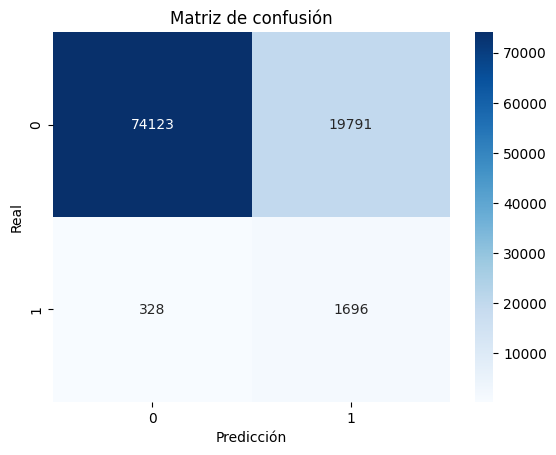

In [28]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

In [29]:
mask_false_negative = (y_test == 1) & (y_pred == 0)
false_negatives = X_test.loc[mask_false_negative]

In [30]:
false_negative_rows = df.loc[false_negatives.index, num_cols_inicial + obj_cols]
false_negative_rows

,age,risk_score,amounts_diff,sex,category_name,hosp_type,age_group_new,category_risk_level
7365,0,1,0,male,pediatrics,government,0,low
5865,55,0,5846,male,cardiac and cardiothoracic surgery,corporate,51-65,low
464875,71,1,0,female,cardiology,corporate,66+,high
365189,66,0,6520,male,radiation oncology,corporate,66+,low
242020,3,0,0,male,cardiac and cardiothoracic surgery,corporate,1-18,low
295869,69,0,0,female,medical oncology,corporate,66+,low
117580,43,0,0,female,nephrology,corporate,36-50,low
39698,50,1,1000,male,cardiology,corporate,36-50,high
210347,66,0,0,male,gastroenterology,corporate,66+,low
268453,62,0,0,female,cardiac and cardiothoracic surgery,government,51-65,low


In [31]:
coefs_df = pd.DataFrame({
    "Variable": covariables,
    "Coeficiente": pipeline.named_steps["clf"].coef_[0]
})

coefs_df = coefs_df.sort_values(by="Coeficiente", ascending=False)
coefs_df

,Variable,Coeficiente
2,amounts_diff,1.923224
1,risk_score,0.658644
0,age,0.528938
17,category_name_nephrology,0.497505
38,category_risk_level_low,0.303992
19,category_name_neurosurgery,0.291902
32,hosp_type_government,0.241515
39,category_risk_level_high,0.216469
18,category_name_neurology,0.151337
27,category_name_pulmonology,0.055970
